12586141


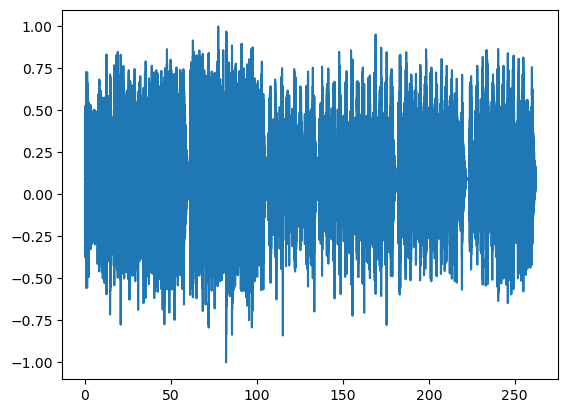

In [1]:
import wave
import numpy
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import filtfilt
from scipy import io
# open the audio file and extract some information
# spf = wave.open('/home/gerald/workspace/src/GuitarMidi-LV2/assets/single-note/Guitar MIDI test.wav','r')
# (nChannels, sampWidth, sampleRate, nFrames, compType, compName) = spf.getparams()

sampleRate,input_signal=io.wavfile.read('../../assets/trainingdata/chords/session_original.wav')
midi_file='../../assets/trainingdata/chords/session_NNTranscription-1-t1.mid'

audio=input_signal#[:,1];

audiomin=numpy.min(audio)
audiomax=numpy.max(audio)

audio=numpy.multiply((audio-audiomin)/(audiomax-audiomin),2)-1
print(len(audio))
nFrames =input_signal.shape[0]
time=numpy.linspace(0,len(audio)/sampleRate,len(audio))

plt.plot(time, audio, label='Input')



# # extract audio from wav file
# input_signal = spf.readframes(-1)


# input_signal = numpy.fromstring(input_signal)
# spf.close()



# # ceate output file
# wav_out = wave.open("output.wav", "w")
# wav_out.setparams((nChannels, sampWidth, sampleRate, nFrames, compType, compName))

# # write to output file
# wav_out.writeframes(output_signal.tobytes())
# wav_out.close()

# # plot the signals
# t = numpy.linspace(0, nFrames/sampWidth, nFrames, endpoint = False)
# plt.plot(t, input_signal, label='Input')
# plt.plot(t, output_signal, label='Output')
# plt.show()


num filters:312
Downsampling data by a factor of 1000...
(312, 12586000)
Downsampled array shape: (312, 12586)
Creating heatmap...


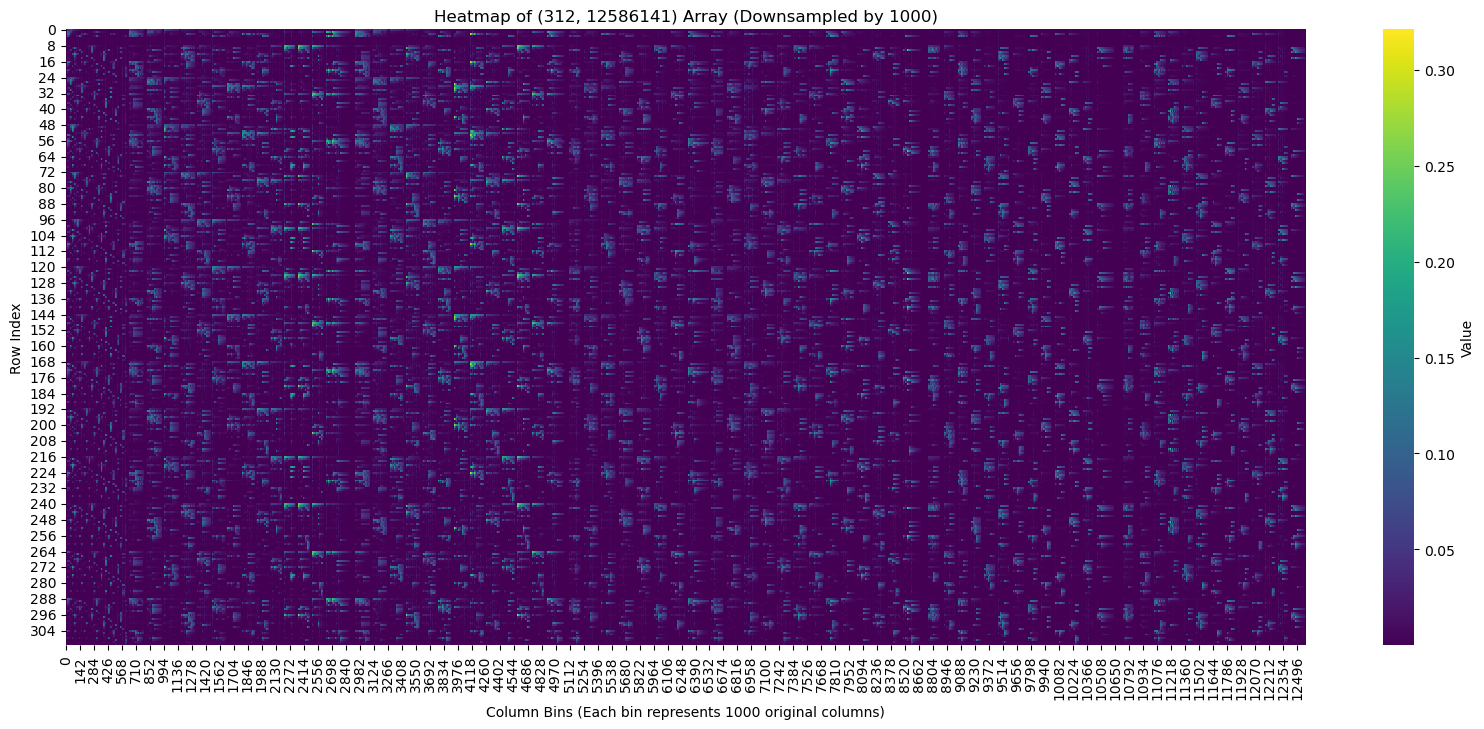

Heatmap displayed.


In [2]:
import numpy as np
import seaborn as sns
num_harmonics=4 
num_frets=13
num_strings=6
class Filter:
    def __init__(self, fret,stringid,harmonic,center_freq, bw,sample_rate):
        self.id=fret*num_strings*num_harmonics+stringid*num_harmonics+harmonic
        self.sample_rate=sample_rate
            
        # create the filter
        N = 2
        low = (center_freq-bw/2) 
        high = (center_freq+bw/2) 
        #self.b, self.a = signal.ellip(N,0.5,40,[low, high], btype='band',fs=sampleRate)
        self.b, self.a =signal.butter(N, [low, high], btype='band',fs=sampleRate)
        
    def process(self,input_audio,filterbank_out: np.array):
        filterbank_out[self.id]=np.abs(signal.filtfilt(self.b, self.a, input_audio))


class HarmonicGroup:
    def __init__(self,fret,stringid ,center_freq, bw,sample_rate):
        self.harmonics=[]
        
        for h in range(1,num_harmonics+1):
            self.harmonics.append(Filter(fret,stringid,h-1,center_freq*h,bw,sample_rate))
    
            
    def process(self, input_audio, filterbank_out: np.array):
        res=filterbank_out
        for h in self.harmonics:
            #filterbank_out.append(h.process(input_audio))
            h.process(input_audio,filterbank_out)
            
        return res
    def get_num_filters(self):
        return len(self.harmonics)
          
            
class Fret:
    def __init__(self,fret,s0,s1,s2,s3,s4,s5, bw,sample_rate):
        
        self.strings=[]
        self.strings.append(HarmonicGroup(fret,0,s0,bw,sample_rate))
   
        self.strings.append(HarmonicGroup(fret,1,s1,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,2,s2,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,3,s3,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,4,s4,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,5,s5,bw,sample_rate))

        
    def process(self, input_audio, filterbank_out: np.array):
    
        for h in self.strings:
            #filterbank_out.append(h.process(input_audio,filterbank_out))
            h.process(input_audio,filterbank_out)
      
    def get_num_filters(self):
        res=0
        for h in self.strings:
            res=res+h.get_num_filters()
            
        return res
            
class FretBoard:
    def __init__(self,bw,sample_rate):
        self.frets=[]
       
        self.frets.append(Fret(0,82,11,147,196,247,329,bw,sample_rate))
        self.frets.append(Fret(1,87,117,156,208,262,349,bw,sample_rate))
        self.frets.append(Fret(2,92,123,165,220,277,370,bw,sample_rate))
        self.frets.append(Fret(3,98,131,175,233,294,392,bw,sample_rate))
        self.frets.append(Fret(4,104,139,185,247,311,415,bw,sample_rate))
        self.frets.append(Fret(5,110,147,196,262,329,440,bw,sample_rate))
        self.frets.append(Fret(6,117,156,208,277,349,466,bw,sample_rate))
        self.frets.append(Fret(7,123,165,220,294,370,494,bw,sample_rate))
        self.frets.append(Fret(8,131,175,233,311,392,523,bw,sample_rate))
        self.frets.append(Fret(9,139,185,247,329,415,554,bw,sample_rate))
        self.frets.append(Fret(10,147,196,262,349,440,587,bw,sample_rate))
        self.frets.append(Fret(11,156,208,277,370,466,622,bw,sample_rate))
        self.frets.append(Fret(12,165,220,294,392,494,659,bw,sample_rate))
        
    def process(self, input_audio, filterbank_out: np.array):
      
        for h in self.frets:
            # filterbank_out.append(h.process(input_audio,filterbank_out))    
            res=h.process(input_audio,filterbank_out)
       
    def get_num_filters(self):
        res=0
        for h in self.frets:
            res=res+h.get_num_filters()
            
        return res

filter =FretBoard(20,sampleRate)
numfilters=filter.get_num_filters()
print('num filters:'+str(numfilters))
audiolength=len(audio)

lencut=len(audio)#50*sampleRate

# lencut=len(audio)
audiocut=audio[:lencut]
# audiocut=np.abs(audiocut)

filterbank_out=np.zeros((numfilters,len(audiocut)))
# print(filterbank_out.shape)
# filterbank_out=np.expand_dims(filterbank_out, axis=0)
filter.process(audiocut,filterbank_out)
# print(filterbank_out.shape)
# print(len(filterbank_out))
# It's best practice to convert your list of lists to a NumPy array.
# Matplotlib can handle lists of lists directly, but NumPy arrays are
# more efficient and offer more features for data manipulation.
# heatmap_data = filterbank_out#np.array(filterbank_out)
def plot_heatmap(plotdata):
    num_cols=plotdata.shape[1]
    num_rows=plotdata.shape[0]
    downsample_factor = 1000
    # --- Downsampling the data ---
    print(f"Downsampling data by a factor of {downsample_factor}...")
    # Calculate the new number of columns after downsampling
    new_num_cols = num_cols // downsample_factor

    # Ensure the original number of columns is a multiple of the downsample_factor
    # If not, you might lose some data at the end or need a more complex aggregation.
    # For simplicity, we'll slice to a multiple of downsample_factor
    effective_cols = new_num_cols * downsample_factor
    data_sliced = plotdata[:, :effective_cols]
    print(data_sliced.shape)
    # Reshape the data for averaging:
    # -1: infer dimension
    # downsample_factor: group columns into blocks
    # num_rows: keep rows as isp
    # This reshapes (19, M*N) to (19, M, N)
    reshaped_data = data_sliced.reshape(num_rows, new_num_cols, downsample_factor)

    # Average along the last axis (the downsample_factor axis)
    downsampled_data = np.max(reshaped_data, axis=2)

    print(f"Downsampled array shape: {downsampled_data.shape}")

    # --- Plotting the Heatmap ---
    print("Creating heatmap...")
    plt.figure(figsize=(20, 8)) # Adjust figure size as needed, especially width for more columns
    sns.heatmap(downsampled_data, cmap='viridis', cbar_kws={'label': 'Value'})
    plt.title(f'Heatmap of ({num_rows}, {num_cols}) Array (Downsampled by {downsample_factor})')
    plt.xlabel(f'Column Bins (Each bin represents {downsample_factor} original columns)')
    plt.ylabel('Row Index')
    plt.show()
    print("Heatmap displayed.")
plot_heatmap(filterbank_out)


Filter Coefficients (b - numerator): [ 2.92597074e-12  0.00000000e+00 -1.17038830e-11  0.00000000e+00
  1.75558245e-11  0.00000000e+00 -1.17038830e-11  0.00000000e+00
  2.92597074e-12]
Filter Coefficients (a - denominator): [  1.          -7.9923371   27.94720933 -55.84417204  69.74451912
 -55.74874407  27.8517771   -7.95143454   0.9931822 ]
Designed a 4th order Elliptic (Cauer) bandpass filter with cutoff frequencies 100 Hz and 120 Hz.
Passband Ripple (rp): 0.5 dB, Stopband Attenuation (rs): 40 dB.


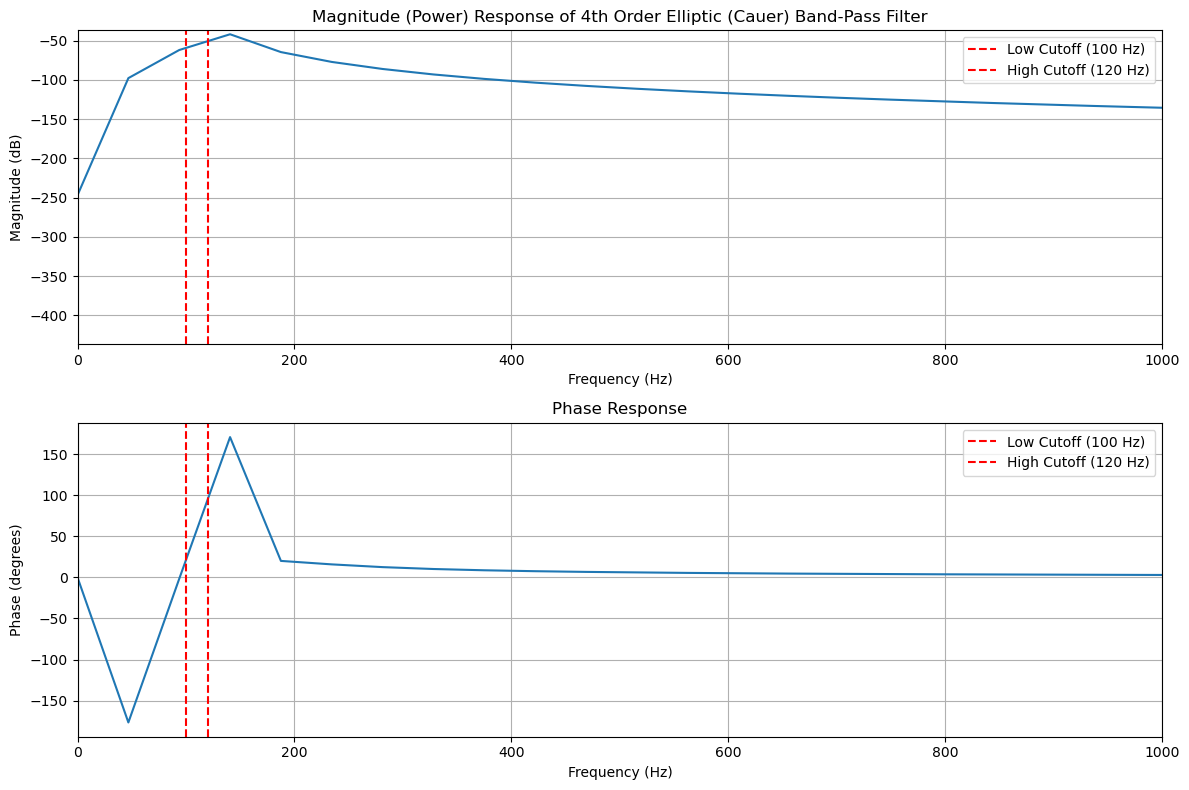


Filter plots generated successfully.
The magnitude plot shows the gain of the filter at different frequencies (in dB).
The phase plot shows the phase shift introduced by the filter at different frequencies (in degrees).


In [3]:


import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Filter Definition ---
# Example: Design a 4th order Elliptic (Cauer) bandpass filter
order = 4
sampling_rate_hz = sampleRate # Specify your actual sampling rate in Hz
low_cutoff_hz = 100     # Lower cutoff frequency in Hz
high_cutoff_hz = 120    # Upper cutoff frequency in Hz

# Elliptic filter specific parameters:
rp = 0.5   # Maximum ripple in the passband (dB)
rs = 40    # Minimum attenuation in the stopband (dB)

# Normalize cutoff frequencies to Nyquist frequency (sampling_rate_hz / 2)
nyquist_freq = 0.5 * sampling_rate_hz
normalized_low_cutoff = low_cutoff_hz / nyquist_freq
normalized_high_cutoff = high_cutoff_hz / nyquist_freq

# Ensure normalized cutoffs are within valid range [0, 1]
if not (0 < normalized_low_cutoff < 1) or not (0 < normalized_high_cutoff < 1):
    print("Warning: Normalized cutoff frequencies are out of expected range (0, 1).")
    print(f"Normalized Low Cutoff: {normalized_low_cutoff:.2f}, Normalized High Cutoff: {normalized_high_cutoff:.2f}")

# Get the filter coefficients (b: numerator, a: denominator) for Elliptic filter
# For bandpass, Wn expects a 2-element sequence [low, high]
#b, a = signal.ellip(order, rp, rs, [normalized_low_cutoff, normalized_high_cutoff], btype='bandpass', analog=False)
b, a = signal.butter(order,  [normalized_low_cutoff, normalized_high_cutoff], btype='bandpass', analog=False)

print(f"Filter Coefficients (b - numerator): {b}")
print(f"Filter Coefficients (a - denominator): {a}")
print(f"Designed a {order}th order Elliptic (Cauer) bandpass filter with cutoff frequencies {low_cutoff_hz} Hz and {high_cutoff_hz} Hz.")
print(f"Passband Ripple (rp): {rp} dB, Stopband Attenuation (rs): {rs} dB.")

# --- Frequency Response Calculation ---
# freqz computes the frequency response of a digital filter.
# w: array of angular frequencies where the response was computed (rad/sample).
# h: frequency response, complex numbers.
# We specify the sampling rate to get frequencies directly in Hz in the output `w`
w, h = signal.freqz(b, a, fs=sampling_rate_hz) # fs parameter returns w in Hz

maxfreq=1000
# frequencies is already in Hz because we passed fs to freqz
frequencies = w

# Calculate magnitude (power) in dB
magnitude_db = 20 * np.log10(abs(h))

# Calculate phase in degrees
phase_degrees = np.unwrap(np.angle(h)) * 180 / np.pi

# --- Plotting ---
plt.figure(figsize=(12, 8))

# Plot 1: Magnitude (Power) Response
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(frequencies, magnitude_db)
plt.title(f'Magnitude (Power) Response of {order}th Order Elliptic (Cauer) Band-Pass Filter')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.axvline(low_cutoff_hz, color='red', linestyle='--', label=f'Low Cutoff ({low_cutoff_hz:.0f} Hz)')
plt.axvline(high_cutoff_hz, color='red', linestyle='--', label=f'High Cutoff ({high_cutoff_hz:.0f} Hz)')
plt.legend()
plt.ylim(min(magnitude_db) - 5, max(magnitude_db) + 5) # Adjust y-limits for better view
plt.xlim(0, maxfreq) # Show frequencies up to sampling rate, or slightly beyond Nyquist

# Plot 2: Phase Response
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(frequencies, phase_degrees)
plt.title('Phase Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (degrees)')
plt.grid(True)
plt.axvline(low_cutoff_hz, color='red', linestyle='--', label=f'Low Cutoff ({low_cutoff_hz:.0f} Hz)')
plt.axvline(high_cutoff_hz, color='red', linestyle='--', label=f'High Cutoff ({high_cutoff_hz:.0f} Hz)')
plt.legend()
plt.xlim(0, maxfreq) # Show frequencies up to sampling rate, or slightly beyond Nyquist

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show()

print("\nFilter plots generated successfully.")
print("The magnitude plot shows the gain of the filter at different frequencies (in dB).")
print("The phase plot shows the phase shift introduced by the filter at different frequencies (in degrees).")



Processing MIDI file: ../../assets/trainingdata/chords/session_NNTranscription-1-t1.mid
Number of tracks: 1


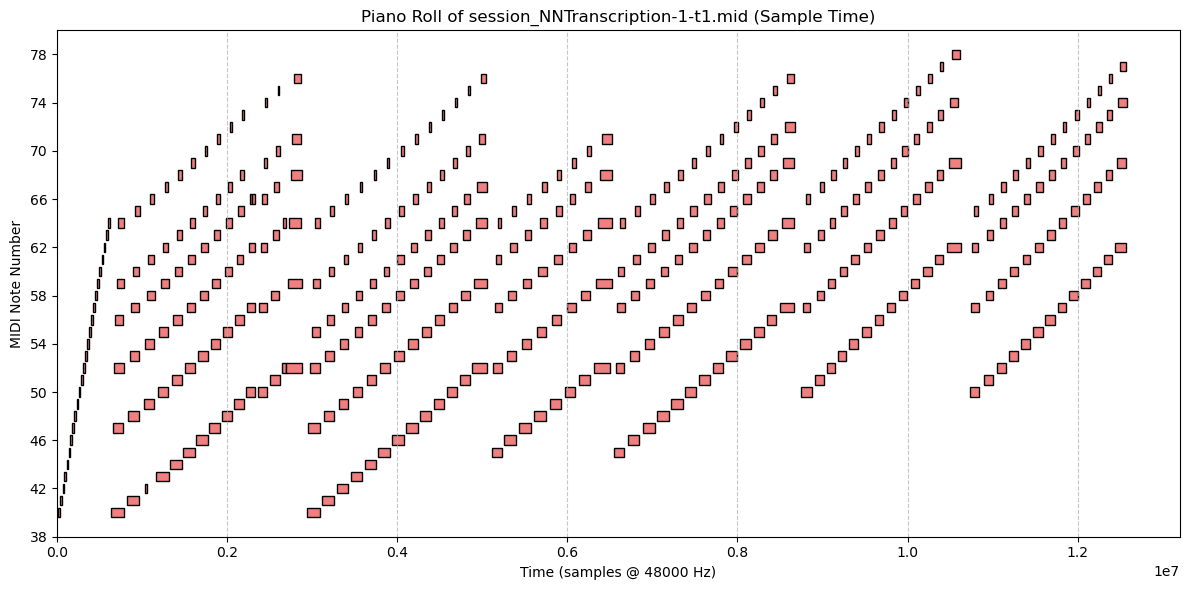

In [4]:
import mido
import matplotlib.pyplot as plt
import numpy as np

def load_midi_to_event_samples(midi_file_path,samplerate):
    """
    Loads MIDI data from a file, extracts note-on/off events,
    and plots them on a piano roll-like graph, converting all
    timestamps to samples based on the provided samplerate.
    Corrected time tracking for accurate absolute positions.

    Args:
        midi_file_path (str): The path to the MIDI file.
        samplerate (int): The audio sample rate (e.g., 44100, 48000)
                          to convert seconds to samples.
    """
    if samplerate <= 0:
        print("Error: Samplerate must be a positive integer.")
        return

    try:
        mid = mido.MidiFile(midi_file_path)
    except FileNotFoundError:
        print(f"Error: MIDI file not found at '{midi_file_path}'")
        return
    except Exception as e:
        print(f"Error loading MIDI file: {e}")
        return

    notes = []
    active_notes = {}
    
    # Absolute time in seconds, calculated from mido's stream iterator
    current_time_in_seconds = 0.0

    print(f"Processing MIDI file: {midi_file_path}")
    print(f"Number of tracks: {len(mid.tracks)}")

    # Iterate through the MIDI file as a whole stream, ordered by absolute time
    # This correctly accounts for inter-track timing and tempo changes.
    for msg in mid.play(): # mid.play() yields messages with msg.time in seconds
        
        # msg.time from mid.play() is the delta from the *previous* event in the *merged* stream
        #print(msg)
        current_time_in_seconds += msg.time 

        if msg.type == 'note_on':
            # Store the note and its start time (in seconds)
            if msg.velocity > 0: 
                active_notes[msg.note] = current_time_in_seconds
            else: # Treat note_on with velocity 0 as note_off
                if msg.note in active_notes:
                    start_sec = active_notes.pop(msg.note)
                    duration_sec = current_time_in_seconds - start_sec
                    notes.append((msg.note, start_sec, duration_sec))

        elif msg.type == 'note_off':
            # Calculate duration when note_off occurs
            if msg.note in active_notes:
                start_sec = active_notes.pop(msg.note)
                duration_sec = current_time_in_seconds - start_sec
                notes.append((msg.note, start_sec, duration_sec))
        
        # Important: Filter out non-note messages that still advance time
        # The 'play()' iterator handles this, but if you were doing manual
        # tick processing, you'd only consider events that affect notes.
        # However, for correct *time*, all messages are important.

    # Handle any notes that were "on" when the file ended (missing note_off)
    # Assign them a duration until the end of the last recorded event
    for note, start_sec in list(active_notes.items()): # Use list() to iterate a copy
        duration_sec = current_time_in_seconds - start_sec
        notes.append((note, start_sec, duration_sec))



    
    return notes

def load_and_plot_midi_in_samples_corrected(midi_file_path, samplerate):
    notes=load_midi_to_event_samples(midi_file_path,samplerate)

    if not notes:
        print("No playable note events found in the MIDI file.")
        return

    # Convert all times from seconds to samples using the provided samplerate
    note_numbers = [n[0] for n in notes]
    start_times_samples = [int(n[1]*samplerate)  for n in notes] 
    durations_samples = [int(n[2]*samplerate) for n in notes]
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))

    for i in range(len(notes)):
        ax.barh(
            y=note_numbers[i],             
            width=durations_samples[i],            
            left=start_times_samples[i],           
            height=0.8,                    
            align='center',
            color='lightcoral', 
            edgecolor='black'
        )

    ax.set_xlabel(f"Time (samples @ {samplerate} Hz)")
    ax.set_ylabel("MIDI Note Number")
    ax.set_title(f"Piano Roll of {midi_file_path.split('/')[-1]} (Sample Time)")

    def midi_to_note_name(midi_note):
        NOTES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
        octave = (midi_note // 12) - 1 
        note_name = NOTES[midi_note % 12]
        return f"{note_name}{octave}"

    # Use the actual min/max of plotted notes for ylim, but ensure it's at least a small range
    if note_numbers:
        min_note = min(note_numbers) - 2
        max_note = max(note_numbers) + 2
    else: # Default for empty notes list
        min_note = 40
        max_note = 80

    ax.set_ylim(min_note, max_note)
    ax.set_xlim(0)
    note_range = max_note - min_note
    if note_range <= 12: 
        y_tick_interval = 1
    elif note_range <= 24: 
        y_tick_interval = 2
    else: 
        y_tick_interval = 4

    y_ticks = np.arange(int(min_note), int(max_note) + 1, y_tick_interval)
    # y_labels = [midi_to_note_name(int(note)) for note in y_ticks]
    ax.set_yticks(y_ticks)
    # ax.set_yticklabels(y_labels)

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
load_and_plot_midi_in_samples_corrected(midi_file,sampleRate)

Processing MIDI file: ../../assets/trainingdata/chords/session_NNTranscription-1-t1.mid
Number of tracks: 1
Downsampling data by a factor of 1000...
(89, 12586000)
Downsampled array shape: (89, 12586)
Creating heatmap...


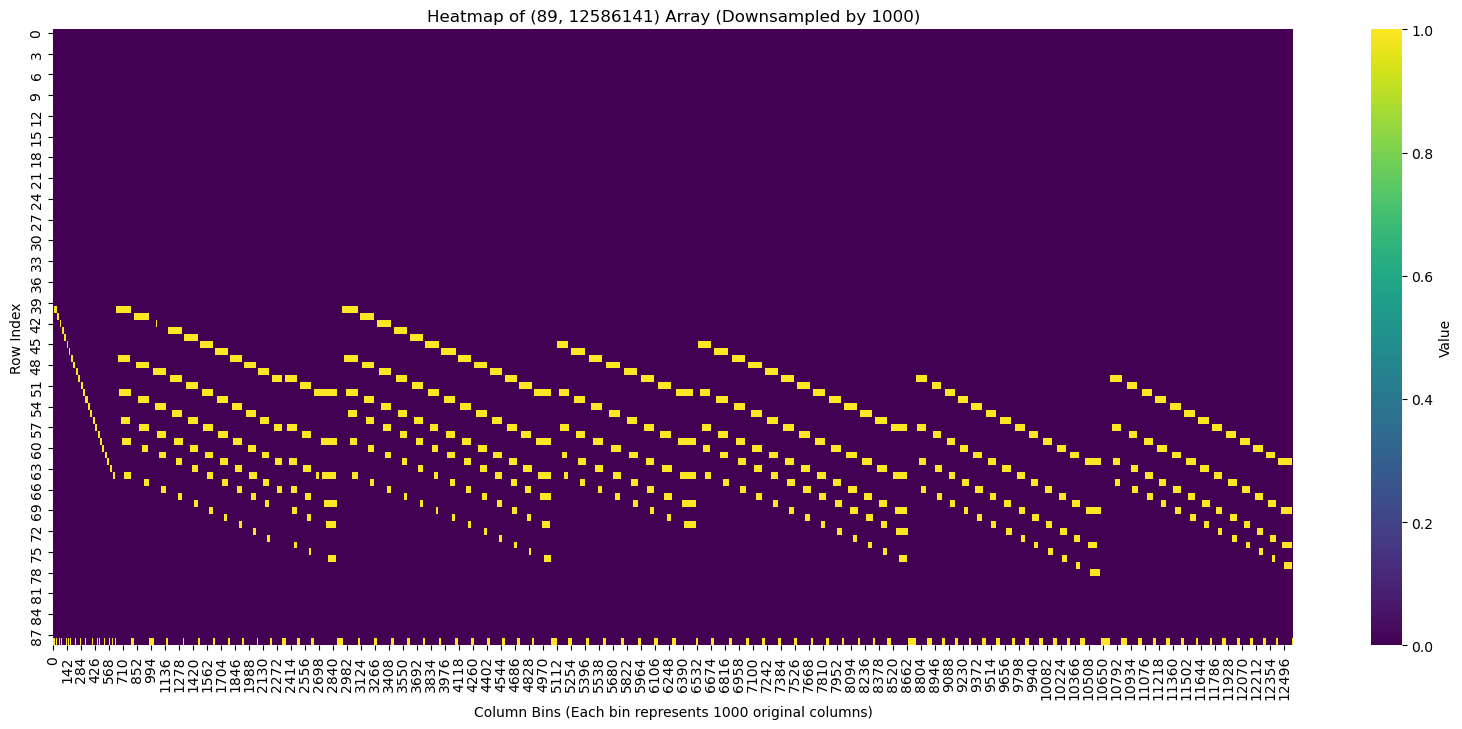

Heatmap displayed.
Downsampling data by a factor of 1000...
(312, 12586000)
Downsampled array shape: (312, 12586)
Creating heatmap...


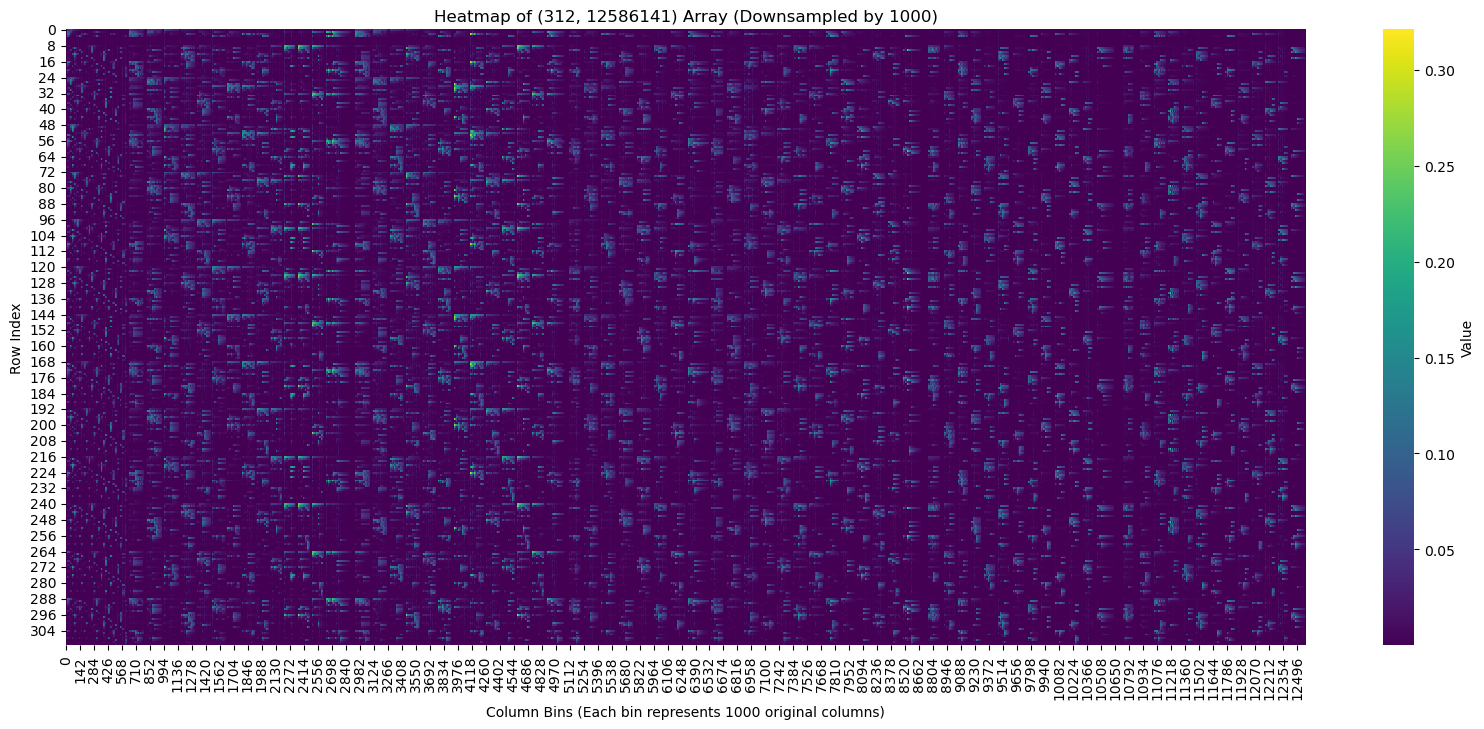

Heatmap displayed.


In [5]:
def generate_midi_classes(midi_file,samplerate,audiolength):
    num_midi_classes=88
    class_matrix=np.zeros((num_midi_classes+1,audiolength))
    notes=load_midi_to_event_samples(midi_file,samplerate)
    
    for n in notes:
        start_sample=int(n[1]*samplerate)
        duration_samples=int(n[2]*samplerate)
        class_matrix[n[0],start_sample:(start_sample+duration_samples)]=1
        
        
    for s in range(0,audiolength):
        midisamplevec=class_matrix[0:num_midi_classes,s]
        class_matrix[num_midi_classes,s]=np.max(midisamplevec)!=1
        
    return class_matrix
 
midi_classes=generate_midi_classes(midi_file,sampleRate,len(audiocut))   
plot_heatmap(midi_classes)
plot_heatmap(filterbank_out)

## Data preperation

In [6]:
frame_size=256
import os
def reshape_to_nn_input(indata):
    num_cols=indata.shape[1]
    num_rows=indata.shape[0]
    downsample_factor = frame_size
    # --- Downsampling the data ---
    print(f"reshape data by a factor of {downsample_factor}...")
    # Calculate the new number of columns after downsampling
    new_num_cols = num_cols // downsample_factor

    # Ensure the original number of columns is a multiple of the downsample_factor
    # If not, you might lose some data at the end or need a more complex aggregation.
    # For simplicity, we'll slice to a multiple of downsample_factor
    effective_cols = new_num_cols * downsample_factor
    data_sliced = indata[:, :effective_cols]
    print(data_sliced.shape)
    # Reshape the data for averaging:
    # -1: infer dimension
    # downsample_factor: group columns into blocks
    # num_rows: keep rows as isp
    # This reshapes (19, M*N) to (19, M, N)
    reshaped_data = data_sliced.reshape(num_rows, new_num_cols, downsample_factor,1)
    reshaped_data=np.swapaxes(reshaped_data,0,1)
    reshaped_data=np.swapaxes(reshaped_data,1,2)
    
    print('Reshaped the input data to  ')
    print(reshaped_data.shape)
    return reshaped_data
    
def reshape_to_nn_output(outdata):
    num_cols=outdata.shape[1]
    num_rows=outdata.shape[0]
    downsample_factor = frame_size
    # --- Downsampling the data ---
    print(f"reshape data by a factor of {downsample_factor}...")
    # Calculate the new number of columns after downsampling
    new_num_cols = num_cols // downsample_factor

    # Ensure the original number of columns is a multiple of the downsample_factor
    # If not, you might lose some data at the end or need a more complex aggregation.
    # For simplicity, we'll slice to a multiple of downsample_factor
    effective_cols = new_num_cols * downsample_factor
    data_sliced = outdata[:, :effective_cols]
    print(data_sliced.shape)
    # Reshape the data for averaging:
    # -1: infer dimension
    # downsample_factor: group columns into blocks
    # num_rows: keep rows as isp
    # This reshapes (19, M*N) to (19, M, N)
    reshaped_data = data_sliced.reshape(num_rows, new_num_cols, downsample_factor)
    reshaped_data=np.max(reshaped_data,axis=2)
    reshaped_data=np.swapaxes(reshaped_data,0,1)
    
    print('Reshaped the output data to  ')
    print(reshaped_data.shape)
    return reshaped_data

nn_input=reshape_to_nn_input(filterbank_out)

nn_output=reshape_to_nn_output(midi_classes)

nn_input[0].shape

nn_output[0].shape

totalsamples=nn_input.shape[0]
batch_size=1
# Directory to save the slices
output_dir_input = 'data_slices/input'
output_dir_output = 'data_slices/output'

# Create directories if they don't exist
os.makedirs(output_dir_input, exist_ok=True)
os.makedirs(output_dir_output, exist_ok=True)
print(f'Saving {totalsamples} samples to disk')
for i in range(0,totalsamples,batch_size):
    current_in=None
    current_out=None
    
    if (totalsamples-i)<batch_size:
        current_in=nn_input[i:]
        current_out=nn_output[i:]
    else:
        current_in=nn_input[i:(i+batch_size)]
        current_out=nn_output[i:(i+batch_size)]
        
    # Define file paths for the current slice
    input_filepath = os.path.join(output_dir_input, f'slice_{i:05d}.npy') # 05d for zero-padding up to 99999
    output_filepath = os.path.join(output_dir_output, f'slice_{i:05d}.npy')

    # Save the slices
    np.save(input_filepath, current_in)
    np.save(output_filepath, current_out)
    if i % 1000 == 0:
        print(f"Saved slice {i}/{totalsamples}")

print(f"Serialization complete. Files saved in '{output_dir_input}' and '{output_dir_output}'.")

        
    




reshape data by a factor of 256...
(312, 12585984)
Reshaped the input data to  
(49164, 256, 312, 1)
reshape data by a factor of 256...
(89, 12585984)
Reshaped the output data to  
(49164, 89)
Saving 49164 samples to disk
Saved slice 0/49164
Saved slice 1000/49164
Saved slice 2000/49164
Saved slice 3000/49164
Saved slice 4000/49164
Saved slice 5000/49164
Saved slice 6000/49164
Saved slice 7000/49164
Saved slice 8000/49164
Saved slice 9000/49164
Saved slice 10000/49164
Saved slice 11000/49164
Saved slice 12000/49164
Saved slice 13000/49164
Saved slice 14000/49164
Saved slice 15000/49164
Saved slice 16000/49164
Saved slice 17000/49164
Saved slice 18000/49164
Saved slice 19000/49164
Saved slice 20000/49164
Saved slice 21000/49164
Saved slice 22000/49164
Saved slice 23000/49164
Saved slice 24000/49164
Saved slice 25000/49164
Saved slice 26000/49164
Saved slice 27000/49164
Saved slice 28000/49164
Saved slice 29000/49164
Saved slice 30000/49164
Saved slice 31000/49164
Saved slice 32000/49164

# Neural net modelling

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files

# --- Essential for GPU memory management ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")

        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True) # Corrected
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
# ---------------------------------------------------------------------------------

print(f"TensorFlow version: {tf.__version__}")

# --- Configuration (using values from serialization part) ---
image_height = 256
image_width = 312
num_channels = 1
num_classes = 89
INPUT_SHAPE = (image_height, image_width, num_channels)
OUTPUT_DIM = num_classes
LEARNING_RATE = 0.001
BATCH_SIZE = 16 # Adjust as needed
EPOCHS = 100

# Directories where slices were saved
input_data_dir = 'data_slices/input'
output_data_dir = 'data_slices/output'

# --- Custom Callback for Live Loss Plotting (remains the same) ---
class PlotLoss(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.val_losses = []
        self.epochs_run = []
        self.fig, self.ax = plt.subplots(figsize=(10, 6))

    def on_epoch_end(self, epoch, logs={}):
        self.losses.append(logs.get('loss'))
        if logs.get('val_loss') is not None:
            self.val_losses.append(logs.get('val_loss'))
        self.epochs_run.append(epoch + 1)

        clear_output(wait=True)
        self.ax.clear()
        self.ax.plot(self.epochs_run, self.losses, label='Training Loss')
        if self.val_losses:
            self.ax.plot(self.epochs_run, self.val_losses, label='Validation Loss')
        self.ax.set_xlabel('Epoch')
        self.ax.set_ylabel('Loss')
        self.ax.set_title('Training and Validation Loss Over Epochs')
        self.ax.legend()
        self.ax.grid(True)
        plt.show()

# --- 1. Define the Pure CNN Model (remains the same) ---
def build_cnn_model(input_shape, output_dim):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape, dtype=tf.float32))

    model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.SpatialDropout2D(0.2))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.SpatialDropout2D(0.2))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.SpatialDropout2D(0.3))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(output_dim, activation='sigmoid', dtype=tf.float32))

    return model

# --- 2. Compile the Model (remains the same) ---
cnn_model = build_cnn_model(INPUT_SHAPE, OUTPUT_DIM)
cnn_model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

# --- 3. Data Loading and Preparation (Stream from Disk - .npy files) ---

# Get lists of all input and output file paths
input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '*.npy')))
output_filepaths = sorted(glob.glob(os.path.join(output_data_dir, '*.npy')))

total_samples_on_disk = len(input_filepaths)
if total_samples_on_disk == 0:
    print(f"ERROR: No .npy files found in {input_data_dir}. Please run the serialization script first.")
    exit()
if total_samples_on_disk != len(output_filepaths):
    print("ERROR: Mismatch in number of input and output files.")
    exit()

print(f"Found {total_samples_on_disk} files on disk.")


# Function to load a single image and its label from file paths
def load_sample_from_files(input_path_tensor, output_path_tensor):
    # Convert TensorFlow string tensors to Python strings
    input_path = input_path_tensor.numpy().decode('utf-8')
    output_path = output_path_tensor.numpy().decode('utf-8')

    # Load the NumPy arrays
    image = np.load(input_path).astype(np.float32).reshape(INPUT_SHAPE)
    
    label = np.load(output_path).astype(np.float32).reshape(OUTPUT_DIM)

    # Ensure the image has the correct shape (H, W, C)
    image = tf.ensure_shape(image, INPUT_SHAPE)
    label = tf.ensure_shape(label, (OUTPUT_DIM,)) # Ensure label shape is correct

    return image, label


def tf_load_sample_from_files(ipath, opath):
    image, label = tf.py_function(
        load_sample_from_files, [ipath, opath], [tf.float32, tf.float32]
    )
    # Explicitly set shapes here!
    image.set_shape(INPUT_SHAPE)
    label.set_shape((OUTPUT_DIM,))
    return image, label
# Create a dataset from the lists of file paths
# These lists of paths are small enough to be held in RAM.
dataset = tf.data.Dataset.from_tensor_slices((input_filepaths, output_filepaths))

# Shuffle the list of paths first
dataset = dataset.shuffle(buffer_size=total_samples_on_disk) # Buffer size for shuffling paths

# Split the dataset into training and validation subsets based on indices
split_ratio = 0.7
num_train = int(total_samples_on_disk * split_ratio)

train_dataset = dataset.take(num_train)
val_dataset = dataset.skip(num_train)

# Map the loading function to the datasets using tf.py_function
# This function will load data from disk for each sample as it's needed
train_dataset = train_dataset.map(
    tf_load_sample_from_files,
    num_parallel_calls=tf.data.AUTOTUNE # Load in parallel threads/processes
)
val_dataset = val_dataset.map(
    tf_load_sample_from_files,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Apply batching and prefetching
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

plot_callback = PlotLoss()

# --- 4. Training the Model ---
print("\n--- Training Pure CNN Model ---")
try:
    history_cnn = cnn_model.fit(train_dataset,
                                epochs=EPOCHS,
                                validation_data=val_dataset,
                                callbacks=[plot_callback])
    cnn_model.save_weights('guitarmidi.weights.h5')
    print("Model weights saved successfully!")
except Exception as e:
    print(f"An error occurred during training: {e}")

2151/2151 ━━━━━━━━━━━━━━━━━━━━ 148s 69ms/step - accuracy: 0.5833 - loss: 0.0114 - val_accuracy: 0.6471 - val_loss: 0.0048
Model weights saved successfully!


1248000
Downsampling data by a factor of 1000...
(312, 1248000)
Downsampled array shape: (312, 1248)
Creating heatmap...


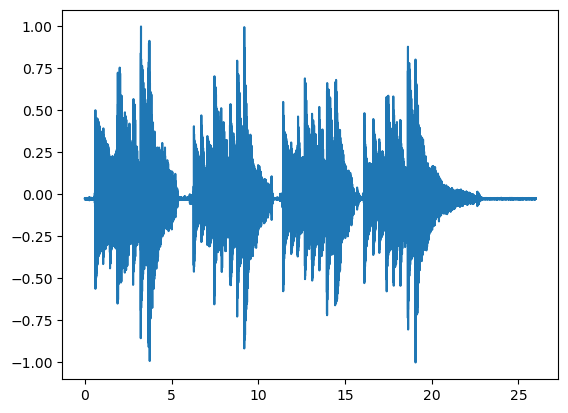

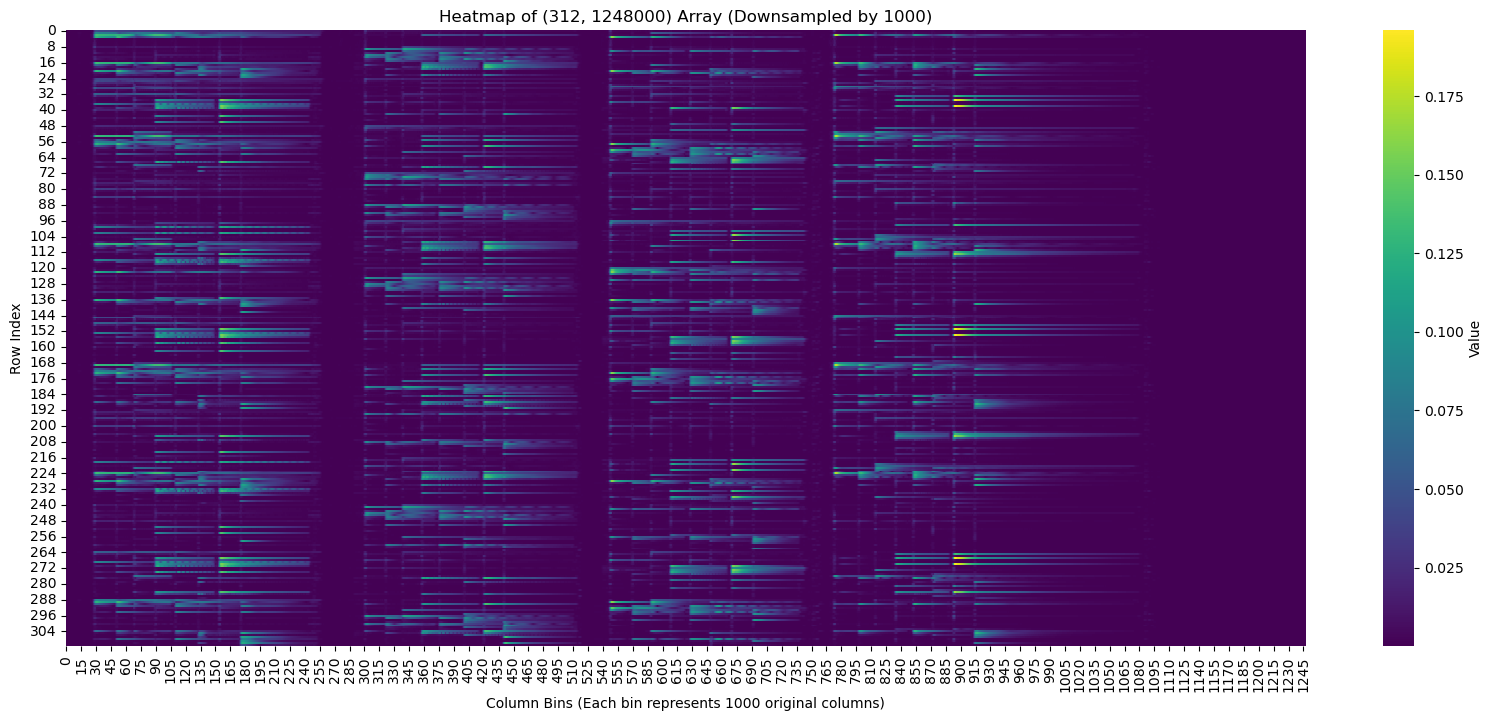

Heatmap displayed.
reshape data by a factor of 256...
(312, 1248000)
Reshaped the input data to  
(4875, 256, 312, 1)


In [8]:
from scipy import io

import numpy
import matplotlib.pyplot as plt
import wave
sampleRate,input_signal_test=io.wavfile.read('../../assets/testdata/E-G-A-B-chords.wav')


audio_test=input_signal_test#[:,1];

audiomin=numpy.min(audio_test)
audiomax=numpy.max(audio_test)

audio_test=numpy.multiply((audio_test-audiomin)/(audiomax-audiomin),2)-1
print(len(audio_test))
nFrames =input_signal_test.shape[0]
time=numpy.linspace(0,len(audio_test)/sampleRate,len(audio_test))

plt.plot(time, audio_test, label='Input')

filterbank_out_test=numpy.zeros((numfilters,len(audio_test)))

filter.process(audio_test,filterbank_out_test)

plot_heatmap(filterbank_out_test)

nn_input_test=reshape_to_nn_input(filterbank_out_test)



(4875, 256, 312, 1)
(256, 312, 1)


2025-07-12 16:38:36.345956: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion', 8 bytes spill stores, 8 bytes spill loads



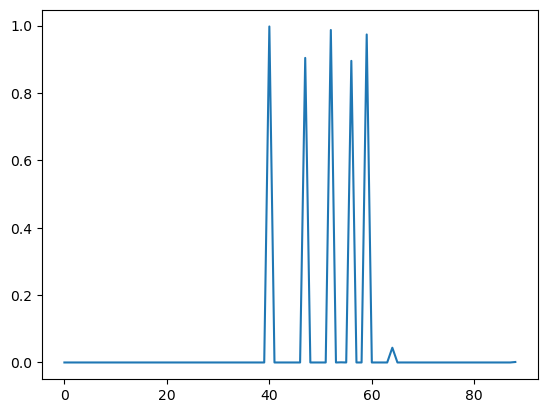

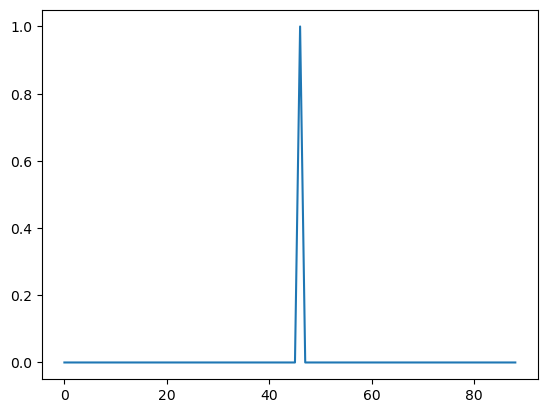

In [9]:
print(nn_input_test.shape)
print(INPUT_SHAPE)
from tensorflow import keras
cnn_model=build_cnn_model(INPUT_SHAPE,OUTPUT_DIM)
cnn_model.load_weights('/home/gmwangi/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.weights.h5')
# dummy_filter_outputs_2d = nn_input_test.reshape(nn_input_test.shape[0],nn_input_test.shape[1],nn_input_test.shape[2])#np.random.rand(256, 288).astype(np.float32)

# print(dummy_filter_outputs_2d.shape)

# # Reshape for the model: (batch_size, time_steps, num_filters, channels)
# # For single inference, batch_size = 1, channels = 1
# input_for_model = np.expand_dims(dummy_filter_outputs_2d[int(200000/256)], axis=0)  # Add batch dimension

# print(input_for_model.shape)
# input_for_model = np.expand_dims(input_for_model, axis=-1) # Add channel dimension

# print(input_for_model.shape)
outsample=160000
predictions_cnn = cnn_model.predict(nn_input_test[range(int(outsample/256),int((outsample+1000)/256))], verbose=0)

# print(predictions_cnn)
xpred=range(1,len(predictions_cnn))
plt.plot(predictions_cnn[0])
plt.show()
plt.plot(nn_output[int(outsample/256)])